<a href="https://colab.research.google.com/github/tinashejm4/default_risk_model/blob/main/default_rating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# I dont have 'good' data for this project. However as a proof of concept i will have to generate synthetic data myself.
np.random.seed(42)

# Generate synthetic MSME data (1000 businesses)
n_samples = 1000
data = {
    'business_age_years': np.random.randint(1, 20, n_samples),
    'annual_revenue_k': np.random.normal(500, 200, n_samples),
    'debt_to_equity_ratio': np.random.uniform(0.1, 5.0, n_samples),
    'sector': np.random.choice(['Retail', 'Manufacturing', 'Services', 'Agri'], n_samples, p = [.5,.1,.2,.2]),
    'prior_defaults': np.random.choice([0, 1], n_samples, p=[0.9, 0.1]),
    'current_ratio': np.random.uniform(0.5, 3.0, n_samples) # Current Assets / Current Liabilities
}

df = pd.DataFrame(data)

df.describe()



,business_age_years,annual_revenue_k,debt_to_equity_ratio,prior_defaults,current_ratio
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,9.746000,498.164437,2.543357,0.095000,1.749375
std,5.651497,194.665419,1.419289,0.293362,0.726714
min,1.000000,-196.161766,0.100057,0.000000,0.509796
25%,5.000000,362.222971,1.408041,0.000000,1.114319
50%,9.000000,504.032881,2.535876,0.000000,1.726665
75%,15.000000,625.003008,3.742138,0.000000,2.390554
max,19.000000,1093.002070,4.989322,1.000000,2.998652


Now to finish off we have to define the target where 'Default' (1 = Yes, 0 = No). The target cannot be fully random because the model will fail to find the relationship between it and the variables we created earlier. Therefore we create a logic where high debt and low current ratio increase default probability.

In [38]:
logit_link = (0.5 * df['debt_to_equity_ratio'] - 0.3 * df['current_ratio'] +
              0.1 * (20 - df['business_age_years']) / 5 + np.random.normal(0, 1, n_samples))
df['default_event'] = (logit_link > 1.5).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Default Rate: {df['default_event'].mean():.2%}")
df.head()

Dataset shape: (1000, 7)
Default Rate: 32.50%


,business_age_years,annual_revenue_k,debt_to_equity_ratio,sector,prior_defaults,current_ratio,default_event
0,7,666.644776,4.126021,Retail,0,2.699594,1
1,15,234.692197,2.350399,Agri,0,2.121707,0
2,11,427.621806,1.853212,Services,0,2.748122,1
3,8,486.082035,2.521641,Services,0,2.058763,0
4,7,597.063199,4.158421,Retail,0,0.828220,1


Next we go to featureengineeering. This is where we determine which features are significant in explaining the defaults. It is also helpful to understand how much each of the feature contibutes to the result.; This is why we arer using a confusion matrix.

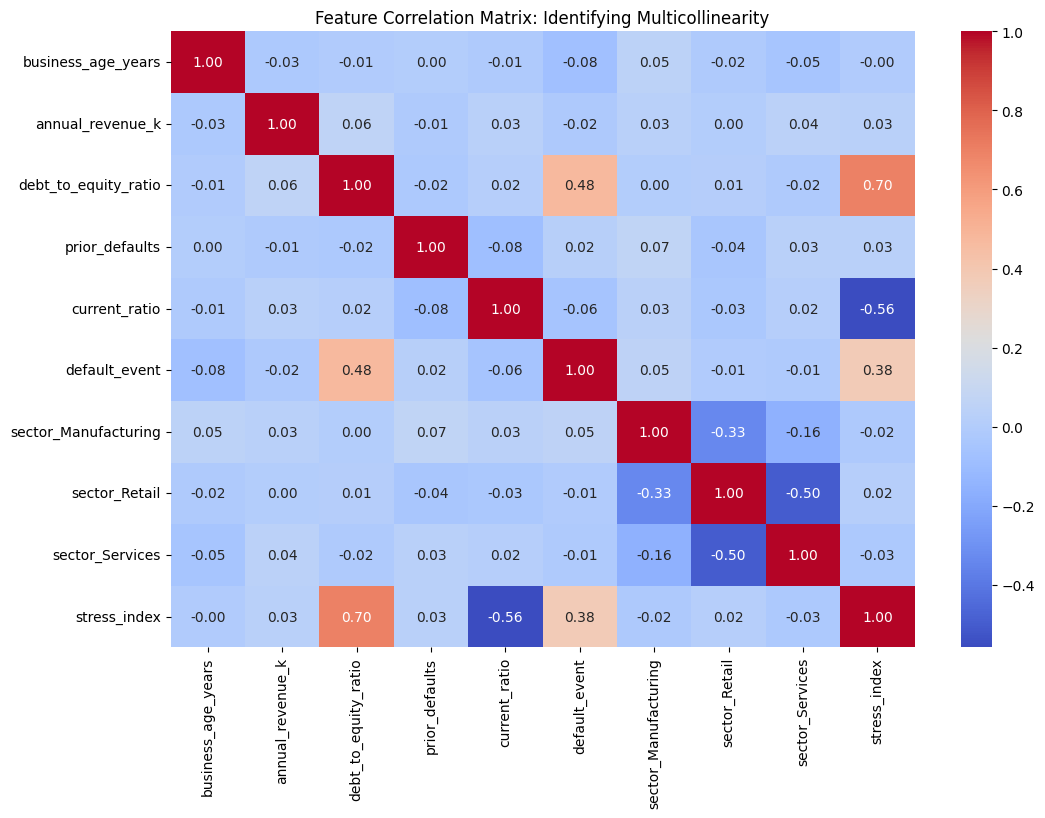

In [39]:
df_original = df.copy(deep=True)


# Convert Sector to dummy variables (One-Hot Encoding)
df = pd.get_dummies(df, columns=['sector'], drop_first=True)


# 1. Feature Engineering: Create a 'Financial Stress Index'
# High Debt + Low Liquidity = High Stress
df['stress_index'] = df['debt_to_equity_ratio'] / (df['current_ratio'] + 0.1)

# 2. Statistical Check: Correlation Matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix: Identifying Multicollinearity")
plt.show()

This matrix tells a coherent financial story:

- Highly leveraged firms are more stressed.

- Stressed firms are more likely to default.

- Firms with strong liquidity are less stressed.

- Business age, revenue, and sector don’t strongly influence default in your sample.

Exacty what we need to start fitting our model.

default_event
0    0.675
1    0.325
Name: proportion, dtype: float64


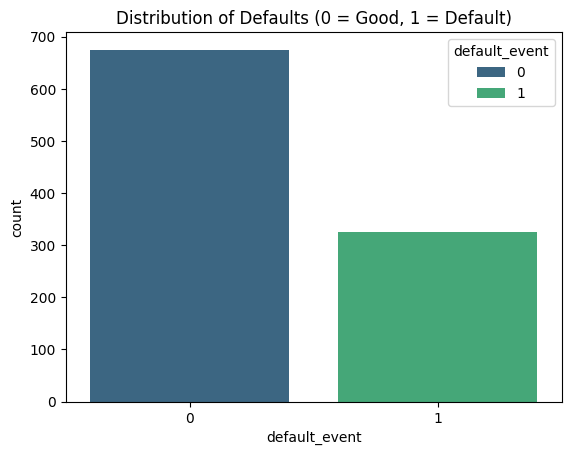

In [40]:
# Check the balance of the target variable
print(df['default_event'].value_counts(normalize=True))

sns.countplot(x='default_event', data=df, palette='viridis', hue='default_event')
plt.title('Distribution of Defaults (0 = Good, 1 = Default)')
plt.show()



Our default rate is 33%.

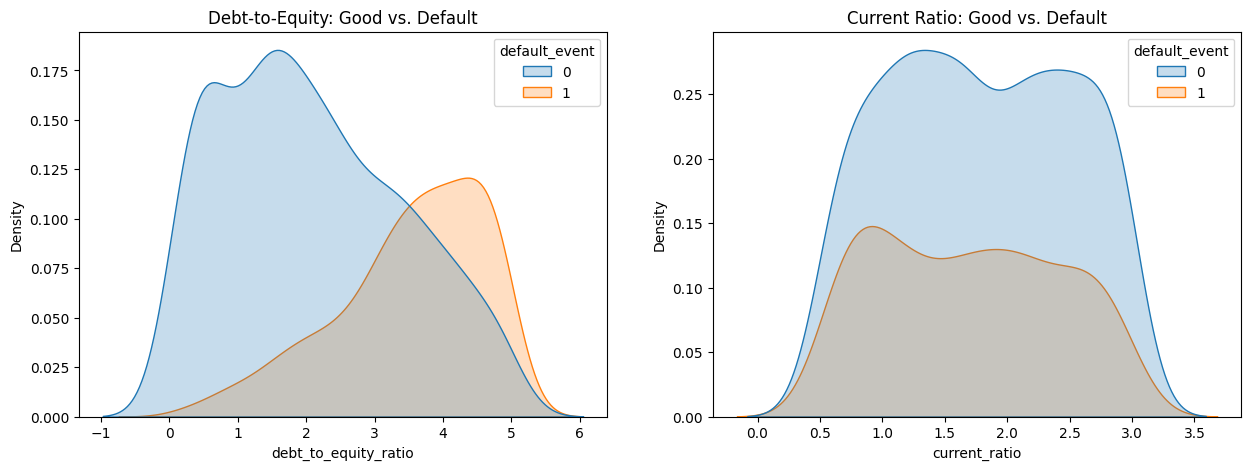

In [41]:
# Compare distributions for 'Debt-to-Equity' and 'Current Ratio'
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(data=df, x='debt_to_equity_ratio', hue='default_event', fill=True, ax=axes[0])
axes[0].set_title('Debt-to-Equity: Good vs. Default')

sns.kdeplot(data=df, x='current_ratio', hue='default_event', fill=True, ax=axes[1])
axes[1].set_title('Current Ratio: Good vs. Default')

plt.show()

Debt to equity ratio is a strong pdefault predictor. The seperation between defaulters and non defaulters is apparent.  Current ratio on the other hand hows weak separation, meaning this feature alone is a poor predictor of default in this current simulation.

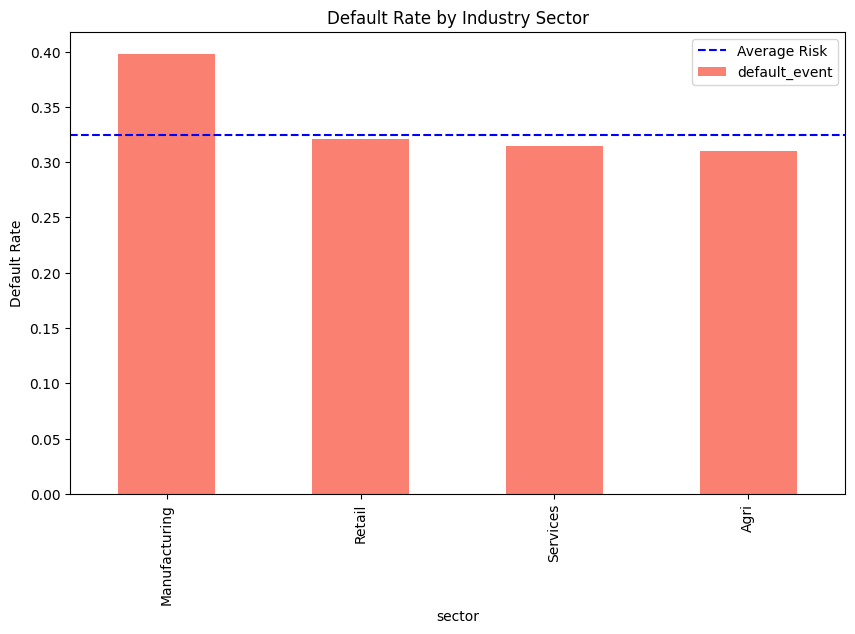

In [42]:
sector_risk = df_original.groupby('sector')['default_event'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sector_risk.plot(kind='bar', color='salmon')
plt.ylabel('Default Rate')
plt.title('Default Rate by Industry Sector')
plt.axhline(df['default_event'].mean(), color='blue', linestyle='--', label='Average Risk')
plt.legend()
plt.show()

Manufacturing has the highest default rates reaching 40%

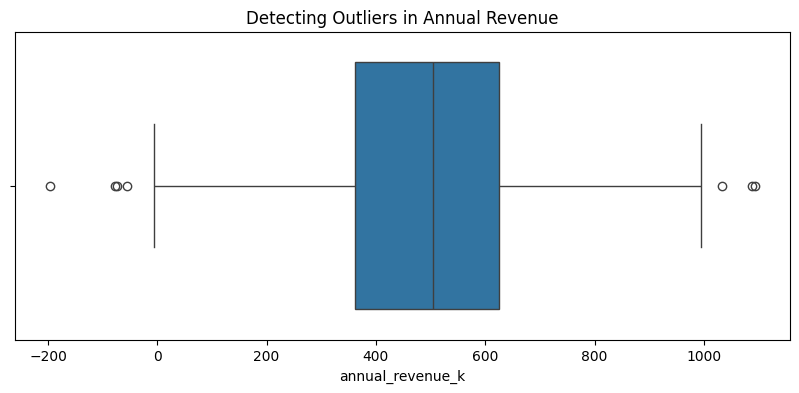

In [43]:
# Boxplot to find extreme values
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['annual_revenue_k'])
plt.title('Detecting Outliers in Annual Revenue')
plt.show()

There are outliers in the annual revenue. To deal with the problem we are going to use the Winzorise method. This method keeps all observations but caps the value at +- .5*Interquartile range.

In [44]:
from sklearn.preprocessing import StandardScaler

# Selecting our features based on EDA
# We'll include the dummy variables we created earlier for 'sector'
features = [col for col in df.columns if col not in ['default_event', 'sector']]
X = df[features]
y = df['default_event']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

We scaled all the features so that the ones with larger values wont be able to overpower the ones with low values.

In [45]:
# Initialize and fit
lr_model = LogisticRegression(class_weight='balanced') # Handling the fact that defaults are rare
lr_model.fit(X_train_scaled, y_train)

# Get predictions
y_pred = lr_model.predict(X_test_scaled)
y_proba = lr_model.predict_proba(X_test_scaled)[:, 1] # Probability of Default

We will use LogisticRegression. To be "meticulous," we'll use a penalty ($L2$ regularization) to prevent the model from over-relying on any single outlier.

After model fitting to test to see how accurate it was. We need to prove the model works using two main metrics, The Confusion Matrix and the AUC-ROC Curve.

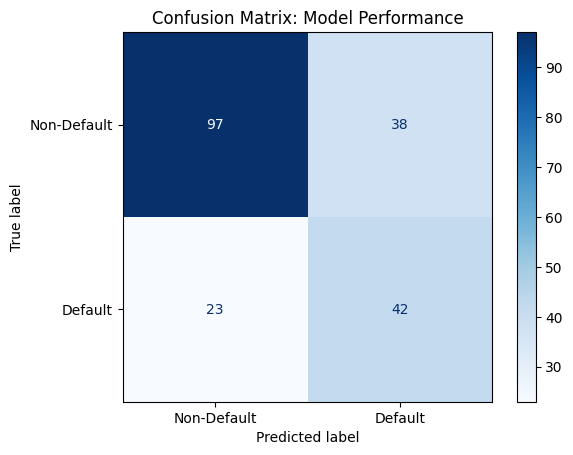

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default', 'Default'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Model Performance")
plt.show()

- Confusion Matrix

This shows where the model got it right and where it failed. For a Credit Analyst, a False Negative is much more expensive than a False Positive.

According to the matrix the model is 69.5% accurate.

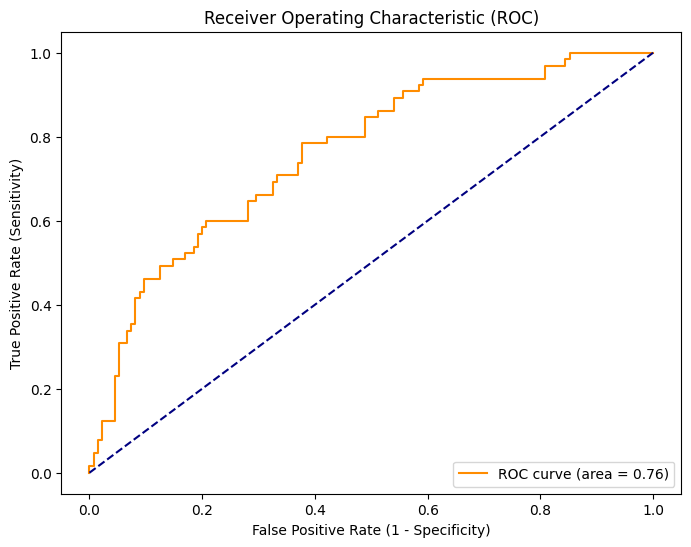

In [47]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

- ROC

The Area Under the Curve (AUC) tells you the probability that the model will rank a randomly chosen "default" higher than a randomly chosen "good" loan.

0.5: No better than a coin flip.

0.7 - 0.8: Good performance.

0.8 - 0.9: Excellent

The ROC curve is 0.76 which is good and better than random choice.

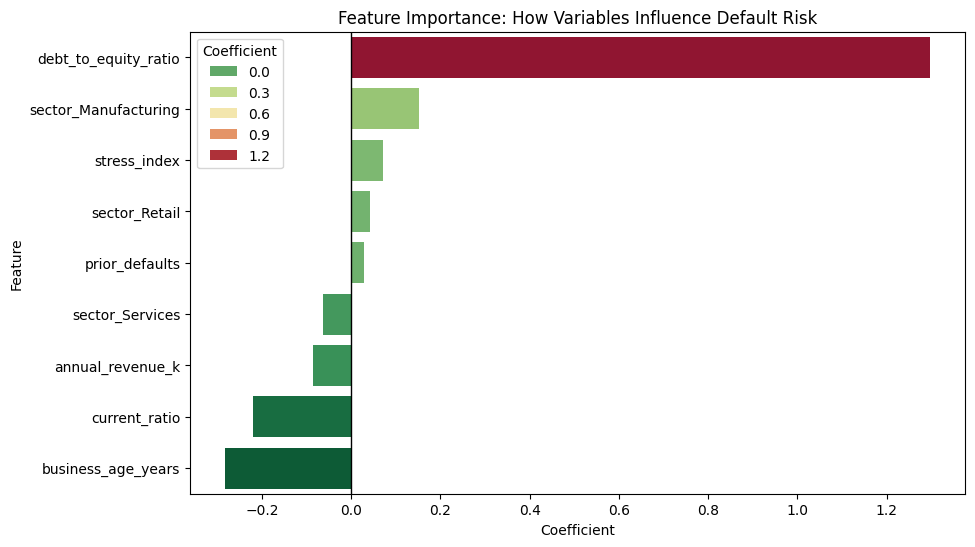

In [51]:
# Create a DataFrame for the coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# Visualize the impact
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='RdYlGn_r', hue  = 'Coefficient')
plt.title('Feature Importance: How Variables Influence Default Risk')
plt.axvline(0, color='black', lw=1)
plt.show()

This graph shows the relationship of every variable to default risk. Debt to equity ratiohas the largest positive effect on default. It is the major predictor of default. Number of years in the bussiness has a negative relationship to default risk, an older business is unlikely to default than a newer business. Other variable like prior defaults dont have much effetc on the risk PD.

My recommendations as a credit analyst:

- The biggest risk driver in this simulation is D/E. Implement a hard cap or a "tiered interest rate" system. Businesses with a D/E ratio above a certain threshold (e.g., 3.5) should either be rejected or charged a higher risk premium.

- Sector Concentration	The model shows Manufacturing is riskier. I suggest Sector Exposure Limits to ensure the porfolio isn't overly concentrated in manufacturing loans.

- New business risk	since business age is a major protector. Create stricter collateral requirements for young businesses such as those under 3 years old to offset their higher natural PD.

- Since Current Ratio is protective, the bank should require quarterly financial statements from borrowers to ensure their liquidity doesn't drop below a safe covenant level.

- Portfolio Diversification to avoid too much exposure to high-risk industries like Retail or hospitality during economic downturns.